In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")  #цветовая палитра



In [2]:
df = pd.read_csv(r'C:\Users\User\Desktop\Walmart_Sales_Analysis\data\Walmart.csv')
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
#ОЧИСТКА ЗНАЧЕНИЙ
print("Пропущенные значения")
print(df.isnull().sum())
print("\n Процент недостающих значений: ")
print((df.isnull().sum() / len(df) * 100).round(2) )

# Общие дубликаты
print("Полных дублирующихся строк:", df.duplicated().sum())
# Дубликаты по магазину и дате
print("Дубликатов по комбинации Store + Date:", 
      df.duplicated(subset=['Store', 'Date']).sum())


print(df.dtypes)

Пропущенные значения
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

 Процент недостающих значений: 
Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64
Полных дублирующихся строк: 0
Дубликатов по комбинации Store + Date: 0
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


In [4]:
df.describe(include='all')


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
unique,NaN,143,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,05-02-2010,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN
mean,23.000000,NaN,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,NaN,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,NaN,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,NaN,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,NaN,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000


In [5]:
#Проверка выбросов

Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['Weekly_Sales'] < Q1 - 1.5*IQR) |
    (df['Weekly_Sales'] > Q3 + 1.5*IQR)
]

print("Outliers:", len(outliers))

Outliers: 34


In [6]:
# Основная описательная статистика
numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print("Описательная статистика для числовых переменных:")
stats_summary = df[numerical_cols].describe().round(2)
print(stats_summary)

# Дополнительно
print("\nДополнительные статистики:")
print("Медиана:")
print(df[numerical_cols].median().round(2))

print("\nСтандартное отклонение:")
print(df[numerical_cols].std().round(2))

Описательная статистика для числовых переменных:
       Weekly_Sales  Temperature  Fuel_Price      CPI  Unemployment
count       6435.00      6435.00     6435.00  6435.00       6435.00
mean     1046964.88        60.66        3.36   171.58          8.00
std       564366.62        18.44        0.46    39.36          1.88
min       209986.25        -2.06        2.47   126.06          3.88
25%       553350.10        47.46        2.93   131.74          6.89
50%       960746.04        62.67        3.44   182.62          7.87
75%      1420158.66        74.94        3.74   212.74          8.62
max      3818686.45       100.14        4.47   227.23         14.31

Дополнительные статистики:
Медиана:
Weekly_Sales    960746.04
Temperature         62.67
Fuel_Price           3.44
CPI                182.62
Unemployment         7.87
dtype: float64

Стандартное отклонение:
Weekly_Sales    564366.62
Temperature         18.44
Fuel_Price           0.46
CPI                 39.36
Unemployment         1.88
dt

In [7]:
# самые большие продажи
print(df['Weekly_Sales'].nlargest(10))
print('\n')
print(df['Weekly_Sales'].nsmallest(10))

1905    3818686.45
2763    3766687.43
1333    3749057.69
527     3676388.98
1762    3595903.20
1814    3556766.03
2815    3555371.03
475     3526713.39
1385    3487986.89
189     3436007.68
Name: Weekly_Sales, dtype: float64


4619    209986.25
4614    213538.32
4675    215359.21
4623    219804.85
4671    220060.35
4605    224031.19
4610    224294.39
4617    224639.76
4653    224806.96
4649    226702.36
Name: Weekly_Sales, dtype: float64


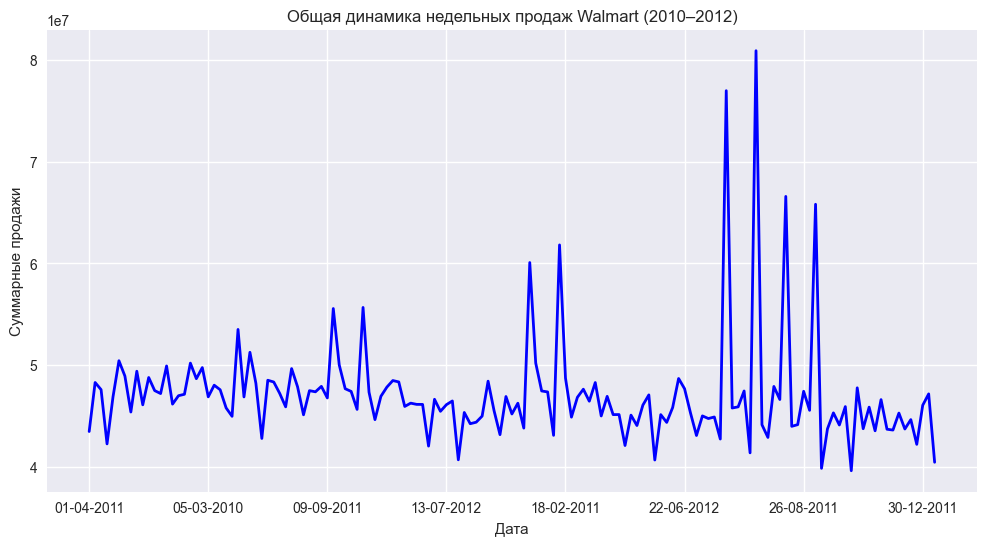

In [8]:
#Графики
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df.groupby('Date')['Weekly_Sales'].sum().plot(linewidth=2, color='blue')
plt.title('Общая динамика недельных продаж Walmart (2010–2012)')
plt.xlabel('Дата')
plt.ylabel('Суммарные продажи')
plt.grid(True)
plt.show()

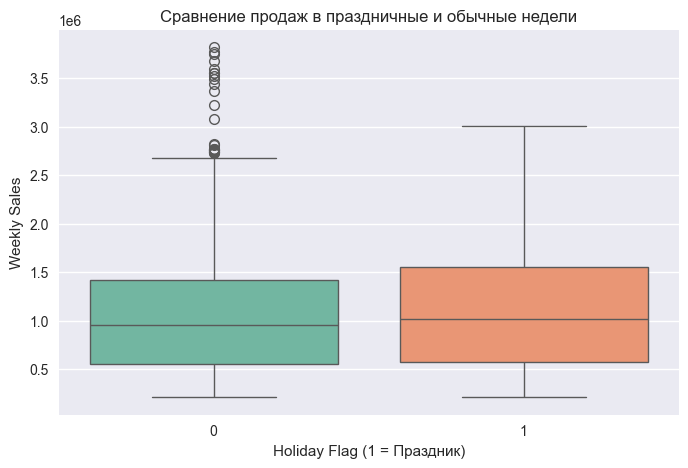

In [9]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Сравнение продаж в праздничные и обычные недели')
plt.xlabel('Holiday Flag (1 = Праздник)')
plt.ylabel('Weekly Sales')
plt.show()

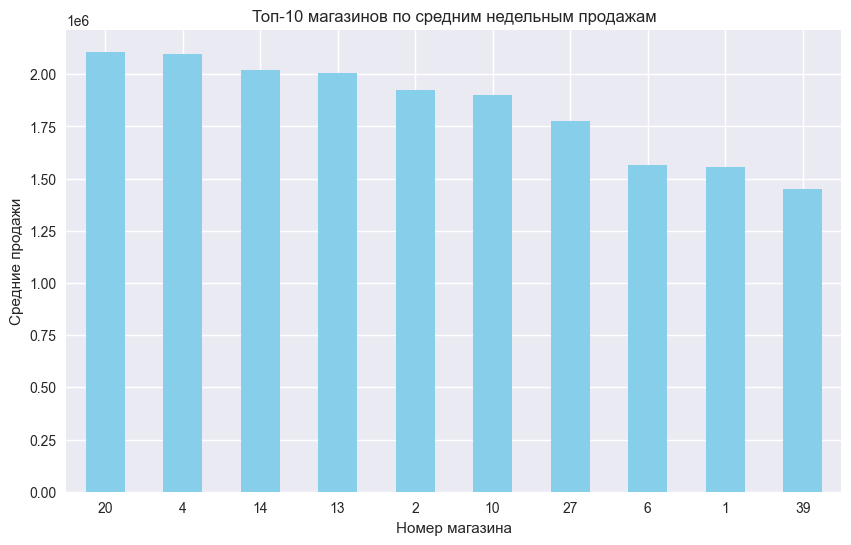

In [10]:
plt.figure(figsize=(10, 6))
top10 = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
top10.plot(kind='bar', color='skyblue')
plt.title('Топ-10 магазинов по средним недельным продажам')
plt.xlabel('Номер магазина')
plt.ylabel('Средние продажи')
plt.xticks(rotation=0)
plt.show()

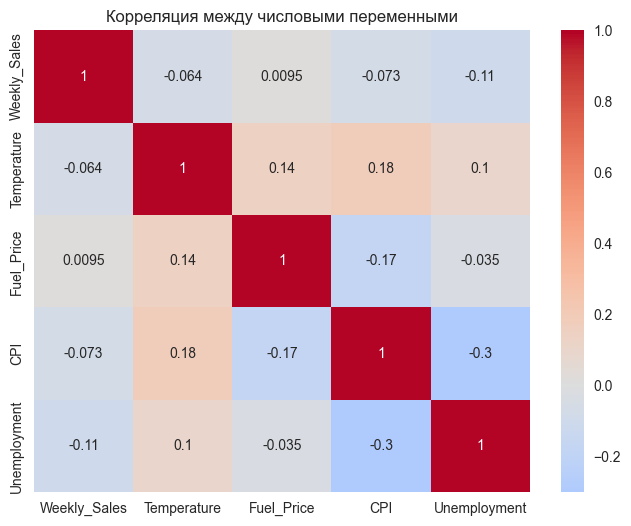

In [11]:
plt.figure(figsize=(8, 6))
numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция между числовыми переменными')
plt.show()

In [12]:
# === DATA TRANSFORMATION ===


# Преобразуем Date в datetime формат
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("Тип Date после преобразования:", df['Date'].dtype)


# === DATA TRANSFORMATION ===

# 1. Извлекаем компоненты даты
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# 2. Категория магазина по уровню продаж
store_avg = df.groupby('Store')['Weekly_Sales'].mean()

df['Store_Category'] = df['Store'].map(
    lambda x: 'High' if store_avg[x] > store_avg.quantile(0.75) else
              'Low' if store_avg[x] < store_avg.quantile(0.25) else 'Medium'
)

# 3. Рост продаж относительно предыдущей недели
df = df.sort_values(['Store', 'Date'])
df['Sales_Growth'] = df.groupby('Store')['Weekly_Sales'].pct_change() * 100

# Проверка результата
print(df[['Date', 'Year', 'Month', 'Quarter', 'Store_Category', 'Sales_Growth']].head(10))
print("\n Новые столбцы успешно созданы!")

Тип Date после преобразования: datetime64[us]
        Date  Year  Month  Quarter Store_Category  Sales_Growth
0 2010-02-05  2010      2        1           High           NaN
1 2010-02-12  2010      2        1           High     -0.105461
2 2010-02-19  2010      2        1           High     -1.826434
3 2010-02-26  2010      2        1           High    -12.546189
4 2010-03-05  2010      3        1           High     10.291285
5 2010-03-12  2010      3        1           High     -7.413468
6 2010-03-19  2010      3        1           High      2.290604
7 2010-03-26  2010      3        1           High     -4.623779
8 2010-04-02  2010      4        2           High     13.566954
9 2010-04-09  2010      4        2           High     -3.106629

 Новые столбцы успешно созданы!


In [13]:
import scipy.stats as stats

# Гипотеза 1
holiday = df[df['Holiday_Flag'] == 1]['Weekly_Sales']
normal = df[df['Holiday_Flag'] == 0]['Weekly_Sales']

print("Средние продажи:")
print(f"Праздничные недели : {holiday.mean():.2f}")
print(f"Обычные недели     : {normal.mean():.2f}")
print(f"Разница            : {holiday.mean() - normal.mean():.2f}")
print(f"Процент            : {(holiday.mean() - normal.mean()) / normal.mean() * 100:.2f}%")

# Статистический тест
stat, p_value = stats.mannwhitneyu(holiday, normal, alternative='greater')
print(f"\np-value = {p_value:.5f}")

Средние продажи:
Праздничные недели : 1122887.89
Обычные недели     : 1041256.38
Разница            : 81631.51
Процент            : 7.84%

p-value = 0.01295


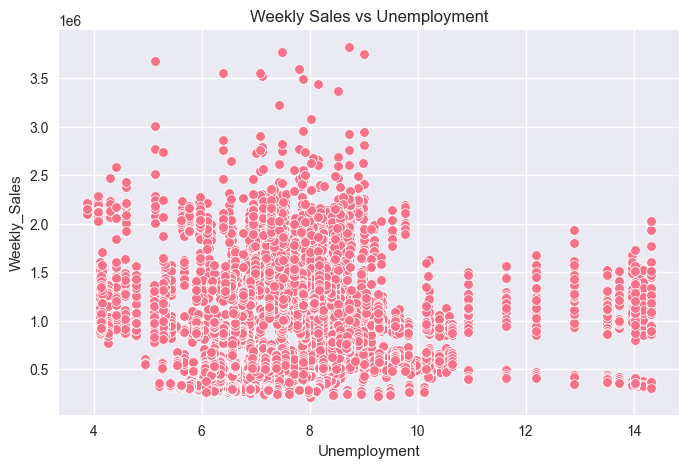

Correlation: -0.106


In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales'
)

plt.title('Weekly Sales vs Unemployment')
plt.show()

corr = df['Weekly_Sales'].corr(df['Unemployment'])

print(f'Correlation: {corr:.3f}')

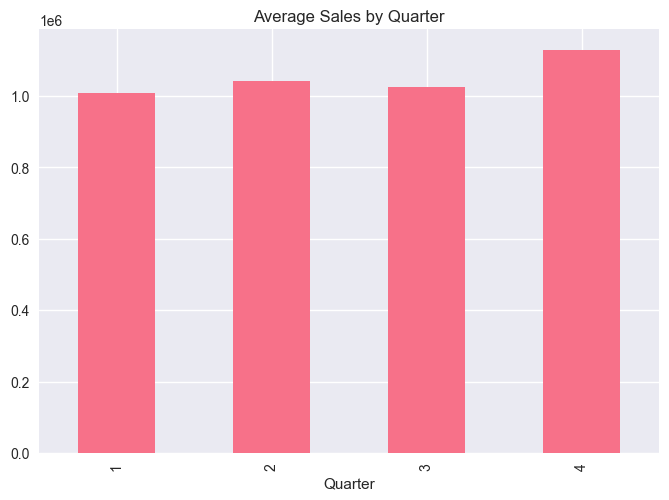

In [15]:
#Продажи по кварталам

quarter_sales = (
    df.groupby('Quarter')
      ['Weekly_Sales']
      .mean()
)

quarter_sales.plot(kind='bar')
plt.title('Average Sales by Quarter')
plt.show()

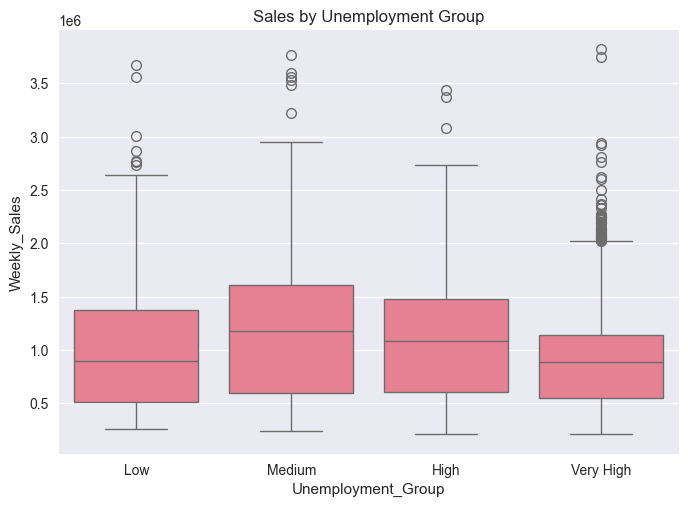

In [16]:
df['Unemployment_Group'] = pd.qcut(
    df['Unemployment'],
    4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

sns.boxplot(
    data=df,
    x='Unemployment_Group',
    y='Weekly_Sales'
)

plt.title(
    'Sales by Unemployment Group'
)

plt.show()

In [17]:
#Еще одна корреляция

corr = (
    df.corr(numeric_only=True)
      ['Weekly_Sales']
      .sort_values(ascending=False)
)

print(corr)

Weekly_Sales    1.000000
Sales_Growth    0.155330
Month           0.076143
WeekOfYear      0.074211
Quarter         0.063363
Holiday_Flag    0.036891
Fuel_Price      0.009464
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64


In [18]:
#Гипотеза 2

from scipy.stats import spearmanr

corr, p = spearmanr(
    df['Unemployment'],
    df['Weekly_Sales']
)

print(f"{corr:.4f}")
print(f"{p:.8f}")
#круто

-0.0624
0.00000056
